<a href="https://colab.research.google.com/github/Peeyusj/week22_vectordb/blob/main/week22_mahabharat_chunks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers langchain langchain-community tiktoken

In [2]:
import urllib.request

url = "https://www.gutenberg.org/cache/epub/19630/pg19630.txt"

# urllib.request.urlopen opens a connection to the URL — like fetch() in JS
# .read() gets the raw bytes
# .decode('utf-8') converts bytes → string
with urllib.request.urlopen(url) as response:
    raw_text = response.read().decode('utf-8')

In [3]:
print(len(raw_text))
print(raw_text.find("BOOK I"))
print(raw_text.find("TRANSLATOR'S EPILOGUE"))

333884
2275
284556


In [4]:
# Strip everything before BOOK I to TRANSLATOR'S EPILOGUE
clean_text = raw_text[2275:284556]
print(len(clean_text))
print(clean_text[:200])

282281
BOOK I

ASTRA DARSANA

(The Tournament)


The scene of the Epic is the ancient kingdom of the Kurus which
flourished along the upper course of the Ganges; and the historical
fact on which the


In [5]:
from langchain_text_splitters import CharacterTextSplitter

splitter = CharacterTextSplitter(
    separator=" ",  # split on spaces (word boundary)
    chunk_size=500, # each chunk = max 500 characters
    chunk_overlap=50 # 50 character overlap between chunks
)

chunks_fixed = splitter.split_text(clean_text)

In [6]:
print(len(chunks_fixed))
print(chunks_fixed[0])
print(chunks_fixed[1])

628
BOOK I

ASTRA DARSANA

(The Tournament)


The scene of the Epic is the ancient kingdom of the Kurus which
flourished along the upper course of the Ganges; and the historical
fact on which the Epic is based is a great war which took place
between the Kurus and a neighbouring tribe, the Panchalas, in the
thirteenth or fourteenth century before Christ.

According to the Epic, Pandu and Dhrita-rashtra, who was born blind,
were brothers. Pandu died early, and Dhrita-rashtra became king
Pandu died early, and Dhrita-rashtra became king of
the Kurus, and brought up the five sons of Pandu along with his
hundred sons.

Yudhishthir, the eldest son of Pandu, was a man of truth and piety;
Bhima, the second, was a stalwart fighter; and Arjun, the third son,
distinguished himself above all the other princes in arms. The two
youngest brothers, Nakula and Sahadeva, were twins. Duryodhan was
the eldest son of Dhrita-rashtra and was jealous of his cousins, the
sons of Pandu. A


In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ".", " "],
    chunk_size=500, # each chunk = max 500 characters
    chunk_overlap=50 # 50 character overlap between chunks
)
chunks_recursive=splitter.split_text(clean_text)

In [8]:
print(len(chunks_recursive))
print(chunks_recursive[0])
print(chunks_recursive[1])

610
BOOK I

ASTRA DARSANA

(The Tournament)


The scene of the Epic is the ancient kingdom of the Kurus which
flourished along the upper course of the Ganges; and the historical
fact on which the Epic is based is a great war which took place
between the Kurus and a neighbouring tribe, the Panchalas, in the
thirteenth or fourteenth century before Christ.

According to the Epic, Pandu and Dhrita-rashtra, who was born blind,
were brothers. Pandu died early, and Dhrita-rashtra became king of
the Kurus, and brought up the five sons of Pandu along with his
hundred sons.

Yudhishthir, the eldest son of Pandu, was a man of truth and piety;
Bhima, the second, was a stalwart fighter; and Arjun, the third son,
distinguished himself above all the other princes in arms. The two
youngest brothers, Nakula and Sahadeva, were twins. Duryodhan was
the eldest son of Dhrita-rashtra and was jealous of his cousins, the


In [9]:
print("FIXED:")
print(chunks_fixed[0])
print("\nRECURSIVE:")
print(chunks_recursive[0])

FIXED:
BOOK I

ASTRA DARSANA

(The Tournament)


The scene of the Epic is the ancient kingdom of the Kurus which
flourished along the upper course of the Ganges; and the historical
fact on which the Epic is based is a great war which took place
between the Kurus and a neighbouring tribe, the Panchalas, in the
thirteenth or fourteenth century before Christ.

According to the Epic, Pandu and Dhrita-rashtra, who was born blind,
were brothers. Pandu died early, and Dhrita-rashtra became king

RECURSIVE:
BOOK I

ASTRA DARSANA

(The Tournament)


The scene of the Epic is the ancient kingdom of the Kurus which
flourished along the upper course of the Ganges; and the historical
fact on which the Epic is based is a great war which took place
between the Kurus and a neighbouring tribe, the Panchalas, in the
thirteenth or fourteenth century before Christ.

According to the Epic, Pandu and Dhrita-rashtra, who was born blind,


In [10]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

/tmp/ipykernel_4817/4246038141.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
# 1. Install the experimental package
!pip install -q langchain-experimental

In [12]:
from langchain_experimental.text_splitter import SemanticChunker

splitter_semantic = SemanticChunker(
    embeddings=embeddings,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=95
)

chunks_semantic = splitter_semantic.split_text(clean_text)

In [13]:
print(len(chunks_semantic))
print(chunks_semantic[0])
print("=-=-=-=-=-=-=-=")
print(chunks_semantic[1])

68
BOOK I

ASTRA DARSANA

(The Tournament)


The scene of the Epic is the ancient kingdom of the Kurus which
flourished along the upper course of the Ganges; and the historical
fact on which the Epic is based is a great war which took place
between the Kurus and a neighbouring tribe, the Panchalas, in the
thirteenth or fourteenth century before Christ. According to the Epic, Pandu and Dhrita-rashtra, who was born blind,
were brothers. Pandu died early, and Dhrita-rashtra became king of
the Kurus, and brought up the five sons of Pandu along with his
hundred sons. Yudhishthir, the eldest son of Pandu, was a man of truth and piety;
Bhima, the second, was a stalwart fighter; and Arjun, the third son,
distinguished himself above all the other princes in arms. The two
youngest brothers, Nakula and Sahadeva, were twins. Duryodhan was
the eldest son of Dhrita-rashtra and was jealous of his cousins, the
sons of Pandu. A tournament was held, and in the course of the day
a warrior named Karna, of

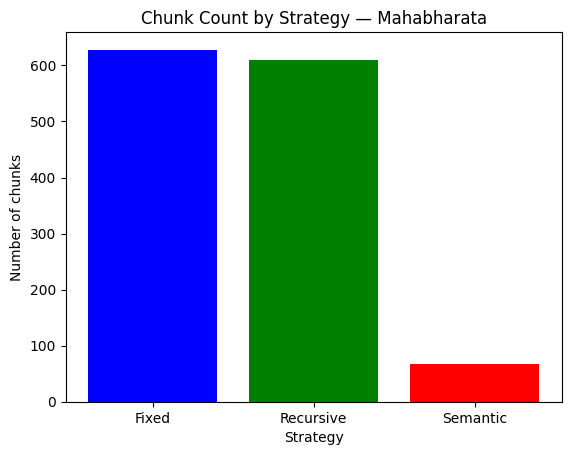

In [14]:
import matplotlib.pyplot as plt

strategies = ['Fixed', 'Recursive', 'Semantic']
chunk_counts = [len(chunks_fixed), len(chunks_recursive), len(chunks_semantic)]

plt.bar(strategies, chunk_counts, color=['blue', 'green', 'red'])
plt.title('Chunk Count by Strategy — Mahabharata')
plt.ylabel('Number of chunks')
plt.xlabel('Strategy')
plt.show()

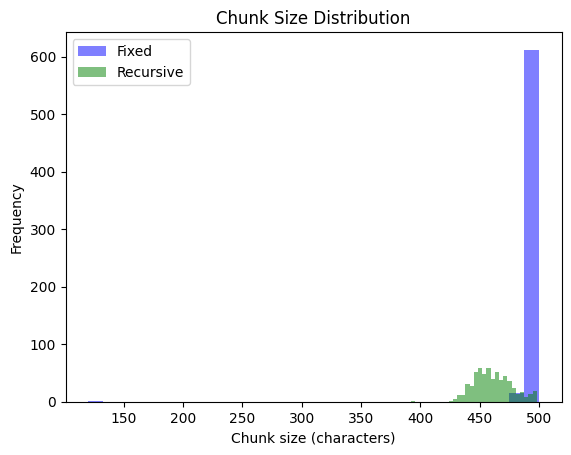

In [15]:
fixed_sizes = [len(c) for c in chunks_fixed]
recursive_sizes = [len(c) for c in chunks_recursive]

plt.hist(fixed_sizes, bins=30, alpha=0.5, label='Fixed', color='blue')
plt.hist(recursive_sizes, bins=30, alpha=0.5, label='Recursive', color='green')
plt.title('Chunk Size Distribution')
plt.xlabel('Chunk size (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [16]:
!pip install chromadb --quiet

In [17]:
!pip install chromadb sentence-transformers google-generativeai --quiet

In [18]:
import chromadb

# Creates a temporary in-memory database — data lives only during this session
client = chromadb.Client()

# Creates a collection — think of it like a table in a database
collection = client.get_or_create_collection("mahabharata")

In [19]:
# Generate embeddings for all chunks
# embed_documents takes a list of strings, returns a list of vectors
chunk_embeddings = embeddings.embed_documents(chunks_recursive)

# Store everything in ChromaDB
collection.add(
    ids=[f"chunk_{i}" for i in range(len(chunks_recursive))],  # ["chunk_0", "chunk_1", ...]
    embeddings=chunk_embeddings,        # 384-dimensional vectors
    documents=chunks_recursive          # original text strings
)

print(f"Stored {collection.count()} chunks in ChromaDB")

Stored 610 chunks in ChromaDB


In [20]:
results = collection.query(
    query_texts=["Who was the strongest warrior in the bettle of mahabharata"],
    n_results=2  # return top 3 most similar chunks
)


for doc in results['documents'][0]:
    print(doc)
    print("---")

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:00<00:00, 104MiB/s]


Strong as death with deadly weapon, facing all his foes he stood,

Arjun too with godlike valour stood unmoved, his bow in hand,
Side by side the dauntless brothers faced the fierce and fiery band!

VIII

Krishna to the Rescue

Krishna knew the sons of Pandu though in robes of Brahmans dressed,
To his elder, Valadeva, thus his inner thoughts expressed:

"Mark that youth with bow and arrow and with lion's lordly gait,
He is helmet-wearing Arjun! greatest warrior midst the great,
---
Forthwith rushed the fiery Arjun in his sounding battle-car,
And like waves before him parted serried ranks of hostile war,

Vainly hurled his lance Duryodhan 'gainst the valiant warrior's face,
Vainly Salya, king of Madra, threw with skill his pond'rous mace,

With disdain the godlike Arjun dashed the feeble darts aside,
Hold aloft his famed _gandiva_ as he stood with haughty pride,

Beat of drum and blare of _sankha_ and the thunder of his car,
---
